In [1]:
list.of.packages <- c("tidyverse","patchwork","ggpubr","data.table","Cairo")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivants sont masqués depuis ‘package:dplyr’:

    between, first, last


L'objet suivant est masqué depuis ‘package:purrr’:

    transpose




In [2]:
T_bins_labels <- c("<=17°C","(17,21]","(21,23]","(23,25]","(25,27]","(27,29]","(29,31]","(31,33]",">33°C")
WB_bins_labels <- c("<=14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")
WB_bins_labels_pretty <- c("≤14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

# Datasets

# Children

In [3]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [4]:
df_children_stats_T <- df_children%>%
                            mutate(T_i30_bin=factor(T_i30_bin,levels=T_bins_labels))%>%
                            filter(!is.na(Children_anemia)&!is.na(T_i30_bin))%>%
                            group_by(T_i30_bin)%>%
                            reframe(N_Ti=n(),
                                    Anemia=factor(Children_anemia,levels=c(1000,0)))%>%
                            group_by(T_i30_bin,Anemia)%>%
                            reframe(N=n(),
                                      N_Ti=first(N_Ti))%>%
                            mutate(perc=N/N_Ti,
                                   Perc=round(perc*100))
head(df_children_stats_T,2)

T_i30_bin,Anemia,N,N_Ti,perc,Perc
<fct>,<fct>,<int>,<int>,<dbl>,<dbl>
<=17°C,1000,17673,31710,0.5573321,56
<=17°C,0,14037,31710,0.4426679,44


In [5]:
df_children_stats_WB <- df_children%>%
                            mutate(WB_i30_bin=factor(WB_i30_bin,levels=WB_bins_labels))%>%
                            filter(!is.na(Children_anemia)&!is.na(WB_i30_bin))%>%
                            group_by(WB_i30_bin)%>%
                            reframe(N_Ti=n(),
                                    Anemia=factor(Children_anemia,levels=c(1000,0)))%>%
                            group_by(WB_i30_bin,Anemia)%>%
                            reframe(N=n(),
                                      N_Ti=first(N_Ti))%>%
                            mutate(perc=N/N_Ti,
                                   Perc=round(perc*100))
head(df_children_stats_WB,2)

WB_i30_bin,Anemia,N,N_Ti,perc,Perc
<fct>,<fct>,<int>,<int>,<dbl>,<dbl>
<=14°C,1000,14794,25569,0.5785913,58
<=14°C,0,10775,25569,0.4214087,42


# Men

In [6]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [7]:
df_men_stats_T <- df_men%>%
                            mutate(T_i30_bin=factor(T_i30_bin,levels=T_bins_labels))%>%
                            filter(!is.na(Men_anemia)&!is.na(T_i30_bin))%>%
                            group_by(T_i30_bin)%>%
                            reframe(N_Ti=n(),
                                      Anemia=factor(Men_anemia,levels=c(1000,0)))%>%
                            group_by(T_i30_bin,Anemia)%>%
                            reframe(N=n(),
                                      N_Ti=first(N_Ti))%>%
                            mutate(perc=N/N_Ti,
                                   Perc=round(perc*100))
head(df_men_stats_T,2)

T_i30_bin,Anemia,N,N_Ti,perc,Perc
<fct>,<fct>,<int>,<int>,<dbl>,<dbl>
<=17°C,1000,3841,15837,0.2425333,24
<=17°C,0,11996,15837,0.7574667,76


In [8]:
df_men_stats_WB <- df_men%>%
                            mutate(WB_i30_bin=factor(WB_i30_bin,levels=WB_bins_labels))%>%
                            filter(!is.na(Men_anemia)&!is.na(WB_i30_bin))%>%
                            group_by(WB_i30_bin)%>%
                            reframe(N_Ti=n(),
                                      Anemia=factor(Men_anemia,levels=c(1000,0)))%>%
                            group_by(WB_i30_bin,Anemia)%>%
                            reframe(N=n(),
                                      N_Ti=first(N_Ti))%>%
                            mutate(perc=N/N_Ti,
                                   Perc=round(perc*100))
head(df_men_stats_WB,2)

WB_i30_bin,Anemia,N,N_Ti,perc,Perc
<fct>,<fct>,<int>,<int>,<dbl>,<dbl>
<=14°C,1000,3222,12856,0.2506223,25
<=14°C,0,9634,12856,0.7493777,75


# Women

In [9]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [10]:
df_women_stats_T <- df_women%>%
                            mutate(T_i30_bin=factor(T_i30_bin,levels=T_bins_labels))%>%
                            filter(!is.na(Women_anemia)&!is.na(T_i30_bin))%>%
                            group_by(T_i30_bin)%>%
                            reframe(N_Ti=n(),
                                      Anemia=factor(Women_anemia,levels=c(1000,0)))%>%
                            group_by(T_i30_bin,Anemia)%>%
                            reframe(N=n(),
                                      N_Ti=first(N_Ti))%>%
                            mutate(perc=N/N_Ti,
                                   Perc=round(perc*100))
head(df_women_stats_T,2)

T_i30_bin,Anemia,N,N_Ti,perc,Perc
<fct>,<fct>,<int>,<int>,<dbl>,<dbl>
<=17°C,1000,52994,110901,0.4778496,48
<=17°C,0,57907,110901,0.5221504,52


In [11]:
df_women_stats_WB <- df_women%>%
                            mutate(WB_i30_bin=factor(WB_i30_bin,levels=WB_bins_labels))%>%
                            filter(!is.na(Women_anemia)&!is.na(WB_i30_bin))%>%
                            group_by(WB_i30_bin)%>%
                            reframe(N_Ti=n(),
                                      Anemia=factor(Women_anemia,levels=c(1000,0)))%>%
                            group_by(WB_i30_bin,Anemia)%>%
                            reframe(N=n(),
                                      N_Ti=first(N_Ti))%>%
                            mutate(perc=N/N_Ti,
                                   Perc=round(perc*100))
head(df_women_stats_WB,2)

WB_i30_bin,Anemia,N,N_Ti,perc,Perc
<fct>,<fct>,<int>,<int>,<dbl>,<dbl>
<=14°C,1000,43822,90287,0.4853633,49
<=14°C,0,46465,90287,0.5146367,51


# Plots

### Define theme

In [12]:
theme_plot <- function(...) {
                  theme(plot.title = element_text(size=30, face = "bold"),
                        legend.position="top",
                        legend.title = element_text(size = 18,face ="bold"),
                        legend.box.margin = margin(5, 5, 5, 5),
                        legend.text = element_text(size = 16),
                        axis.text.x = element_text(size = 16,face ="bold",angle=45,hjust=1),
                        axis.text.y = element_text(size = 16),
                        axis.title.x = element_text(size = 16, hjust = 0.5,face ="bold"),
                        axis.title.y = element_text(size = 16, hjust = 0.5,face ="bold")
                        )
                }

In [13]:
plot_anemia <- function(df_stats, group_label, N_text, WBGT = FALSE) {

  # Pick the temperature column once
  x_var <- if (WBGT) "WB_i30_bin" else "T_i30_bin"
  labels <- if(WBGT) WB_bins_labels else T_bins_labels
  pretty_labels <- if(WBGT) WB_bins_labels_pretty else T_bins_labels_pretty
      
  ggplot(df_stats,
         aes(x = factor(.data[[x_var]]),      # .data pronoun avoids !!sym()
             y = N,
             fill = Anemia)) +
    geom_bar(stat = "identity") +
    theme_bw() +
    labs(x     = if (WBGT) "\n Wet-bulb globe temperature (°C)" else "\n Air Temperature (°C)",
         y     = sprintf("Number of %s\n", group_label)
    ) +
    scale_fill_manual(values = c("orange", "springgreen4"),
                      labels = c("Yes", "No"),
                      name   = "Anemia "
    ) +
    geom_text(data = dplyr::filter(df_stats, N > N_text),
              aes(x     = factor(.data[[x_var]]),
                  y     = N,
                  label = sprintf("%s%%", Perc)
              ),
              position = position_stack(vjust = 0.5),
              colour   = "black"
    ) +
    theme_plot() +
    scale_x_discrete(limits = labels,
                     labels = pretty_labels)      
}

In [14]:
plot_child_anemia_T <- plot_anemia(df_children_stats_T,"children",1000,FALSE)
plot_child_anemia_WB <- plot_anemia(df_children_stats_WB,"children",1000,TRUE)

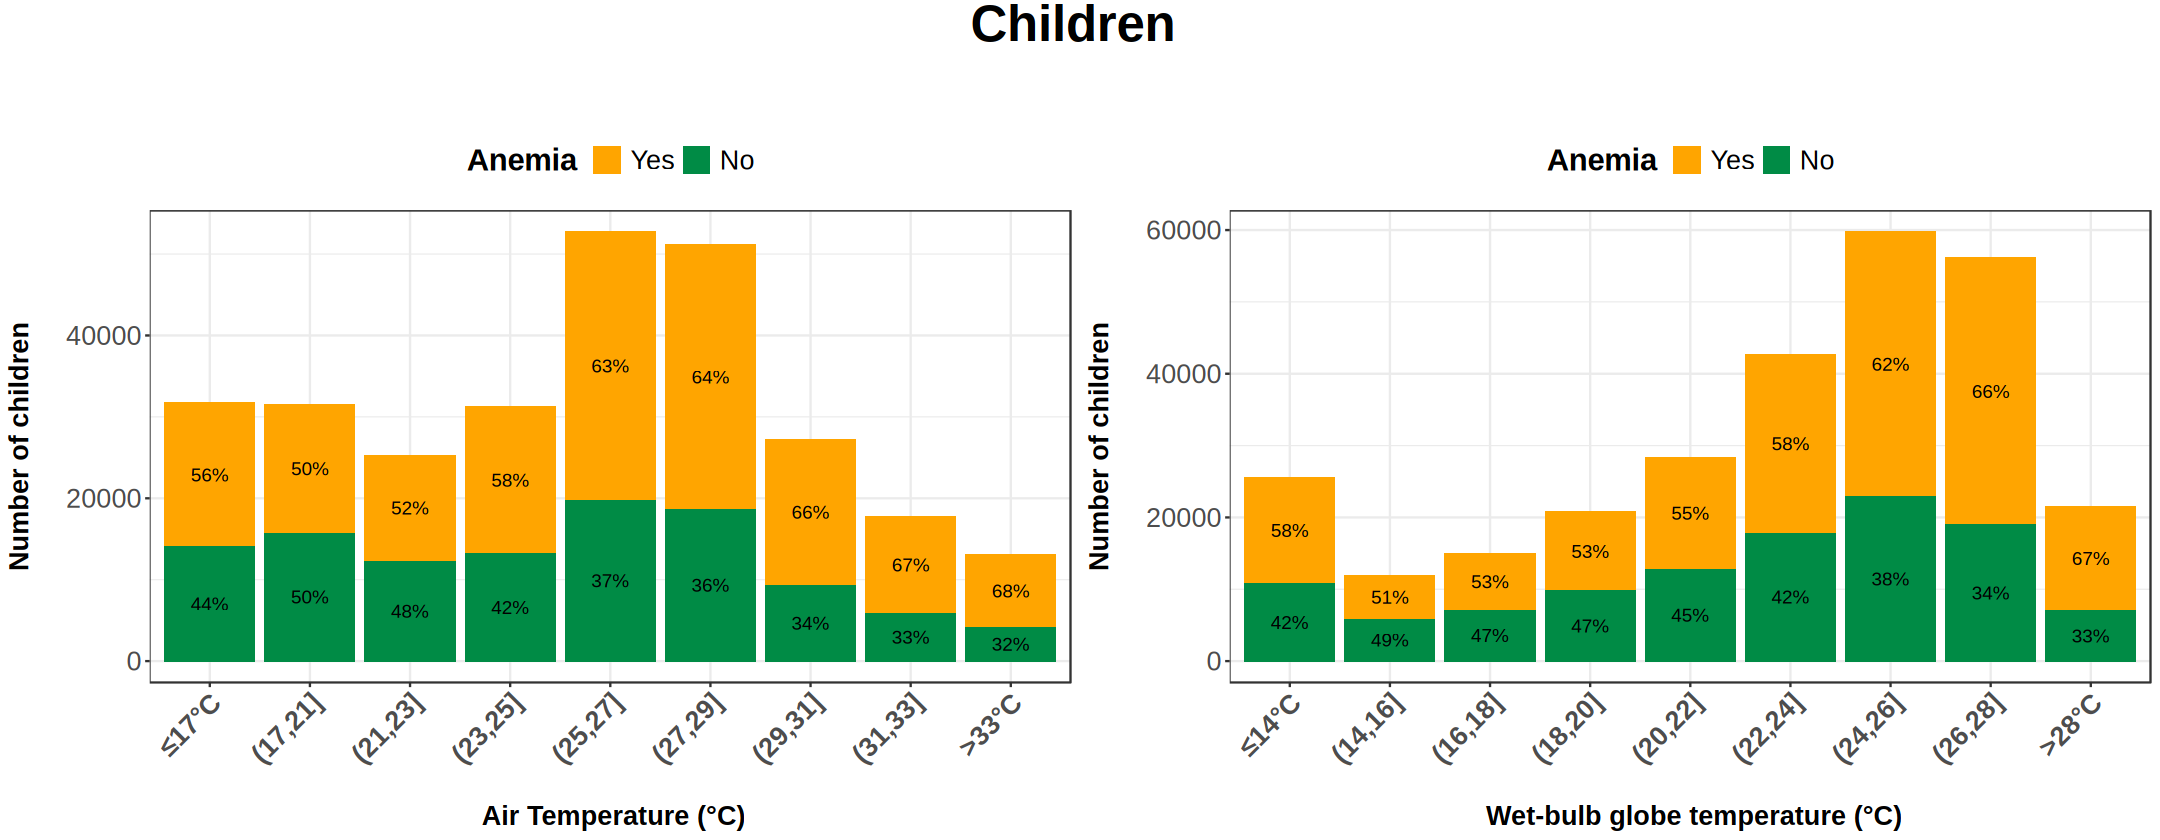

In [15]:
options(repr.plot.width=18, repr.plot.height=7, scipen=9999)

plot_children <- annotate_figure(ggarrange(plot_child_anemia_T,plot_child_anemia_WB,nrow=1,ncol=2),
                                 top=text_grob("Children \n", face="bold", size=30))
plot_children

In [16]:
plot_men_anemia_T <- plot_anemia(df_men_stats_T,"men",700,FALSE)
plot_men_anemia_WB <- plot_anemia(df_men_stats_WB,"men",700,TRUE)

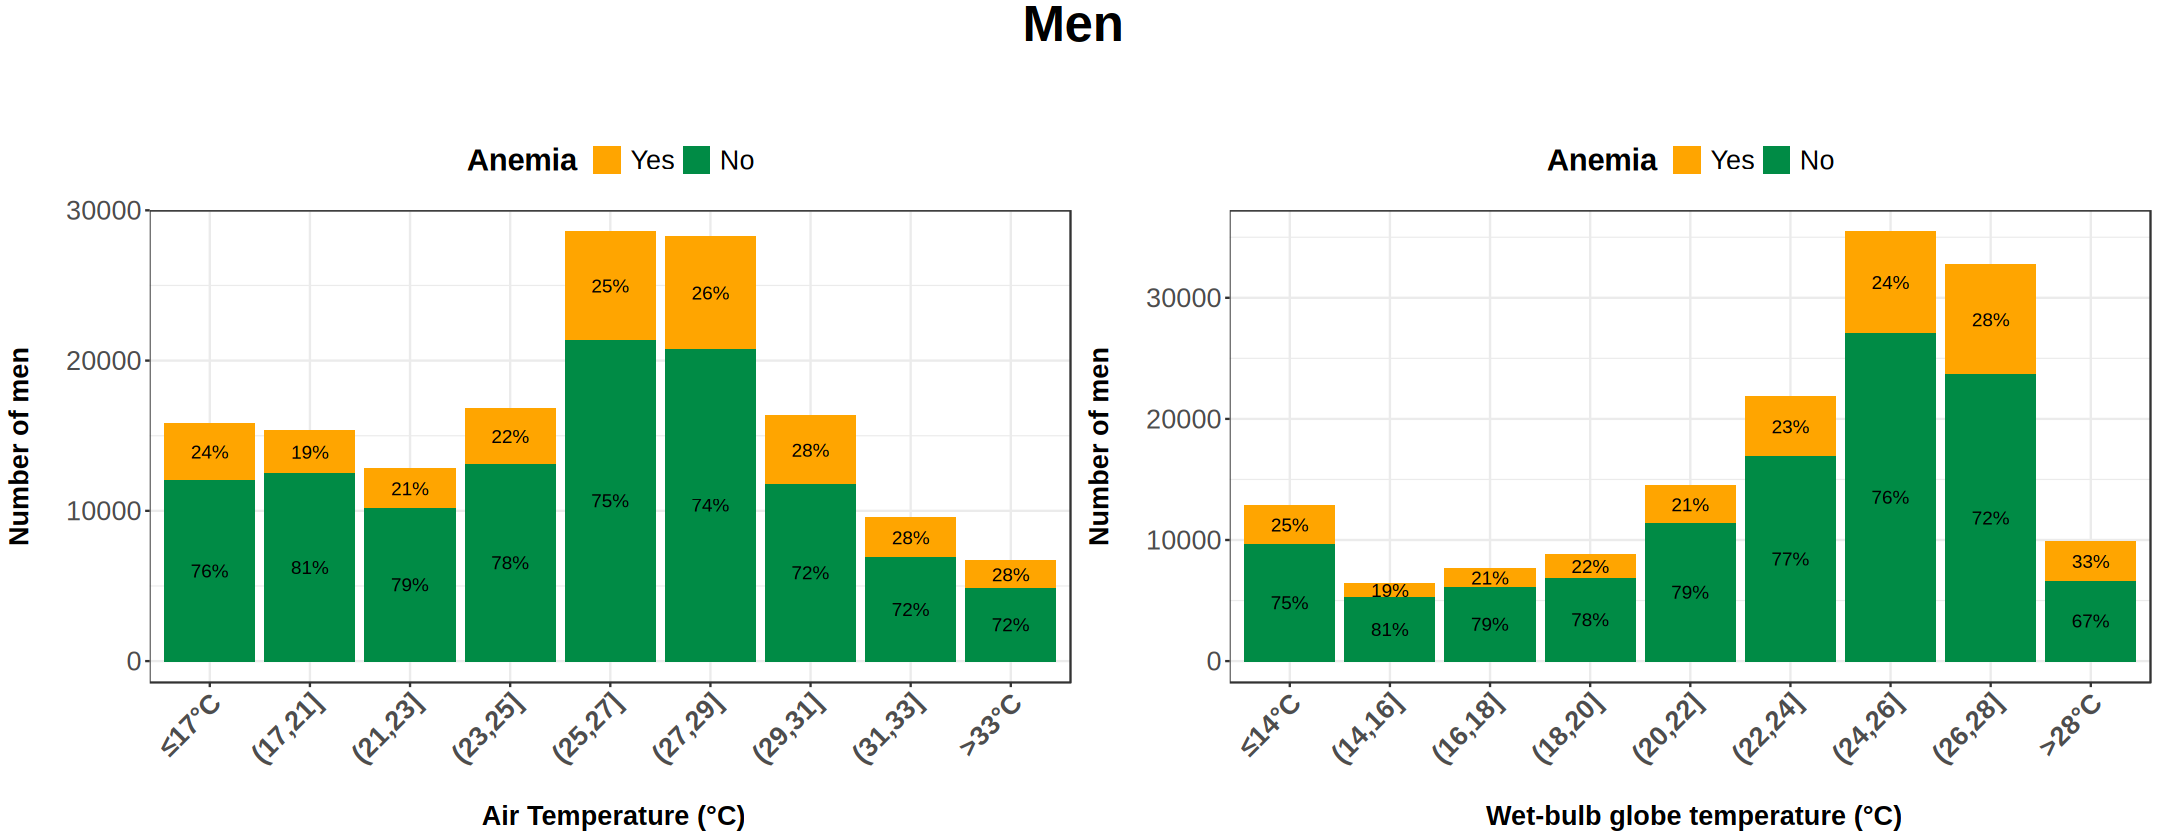

In [17]:
options(repr.plot.width=18, repr.plot.height=7, scipen=9999)

plot_men <- annotate_figure(ggarrange(plot_men_anemia_T,plot_men_anemia_WB,nrow=1,ncol=2),
                                 top=text_grob("Men \n", face="bold", size=30))
plot_men

In [18]:
plot_women_anemia_T <- plot_anemia(df_women_stats_T,"women",2000,FALSE)
plot_women_anemia_WB <- plot_anemia(df_women_stats_WB,"women",2000,TRUE)

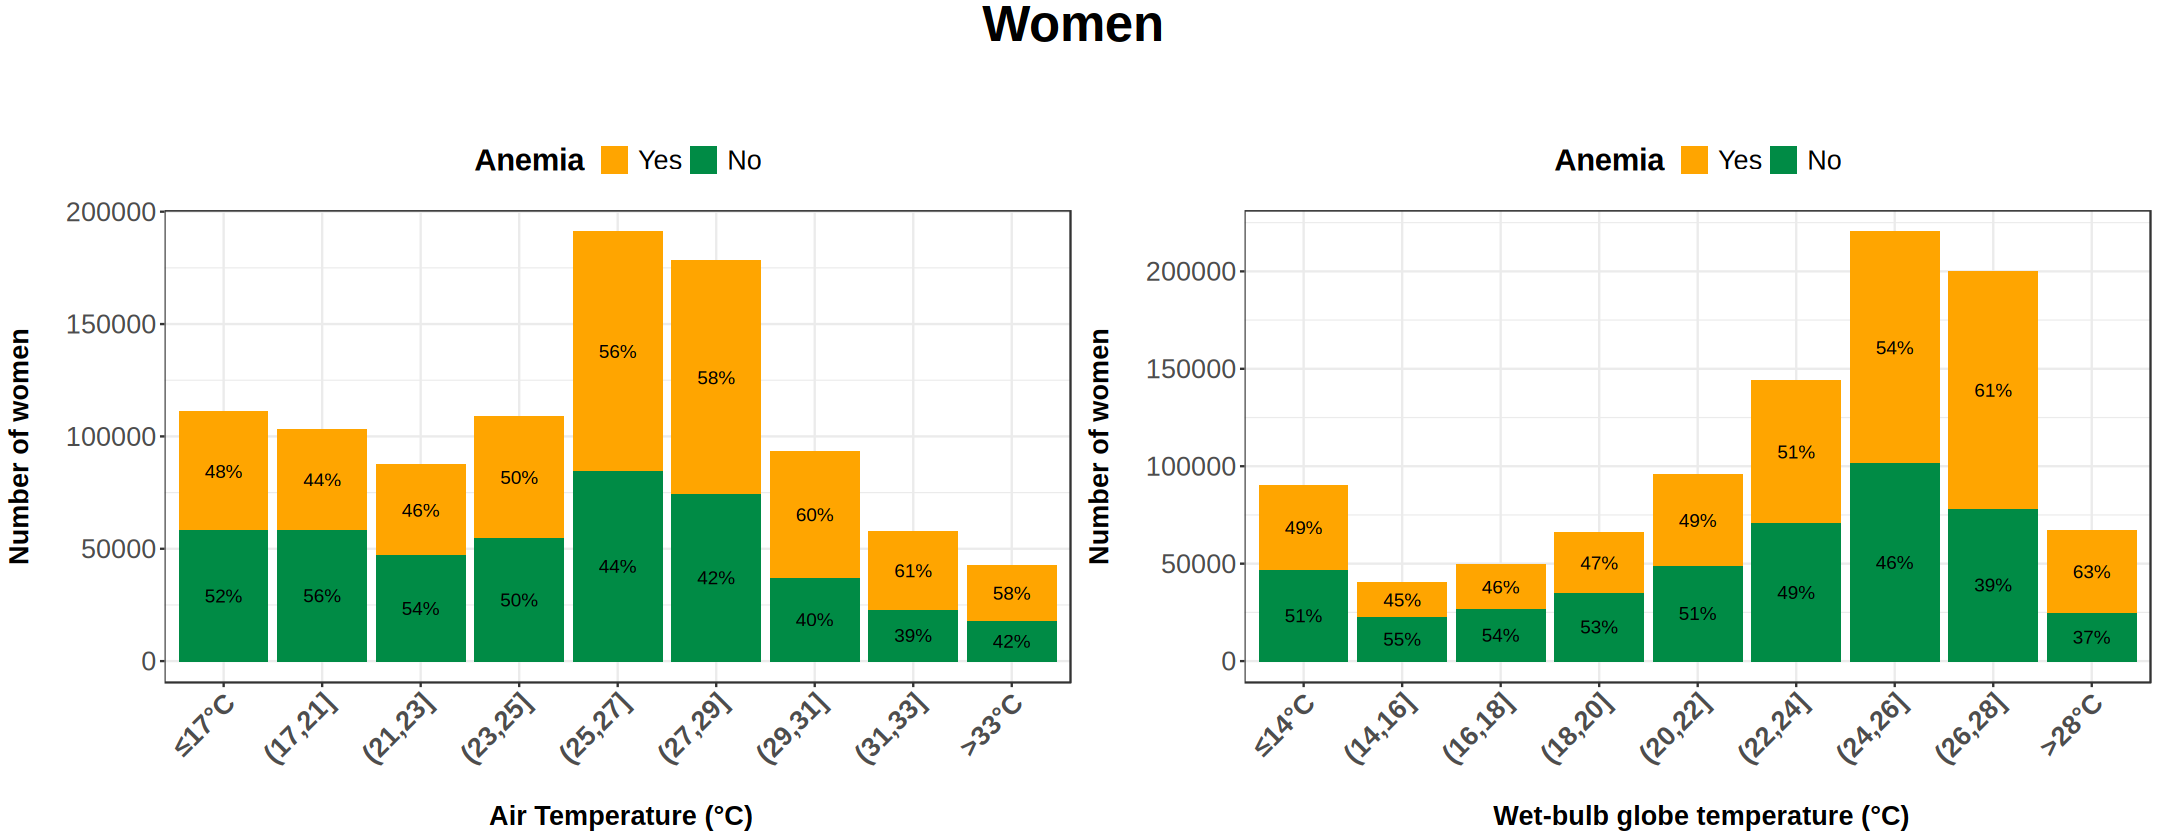

In [19]:
options(repr.plot.width=18, repr.plot.height=7, scipen=9999)

plot_women <- annotate_figure(ggarrange(plot_women_anemia_T,plot_women_anemia_WB,nrow=1,ncol=2),
                                 top=text_grob("Women \n", face="bold", size=30))
plot_women

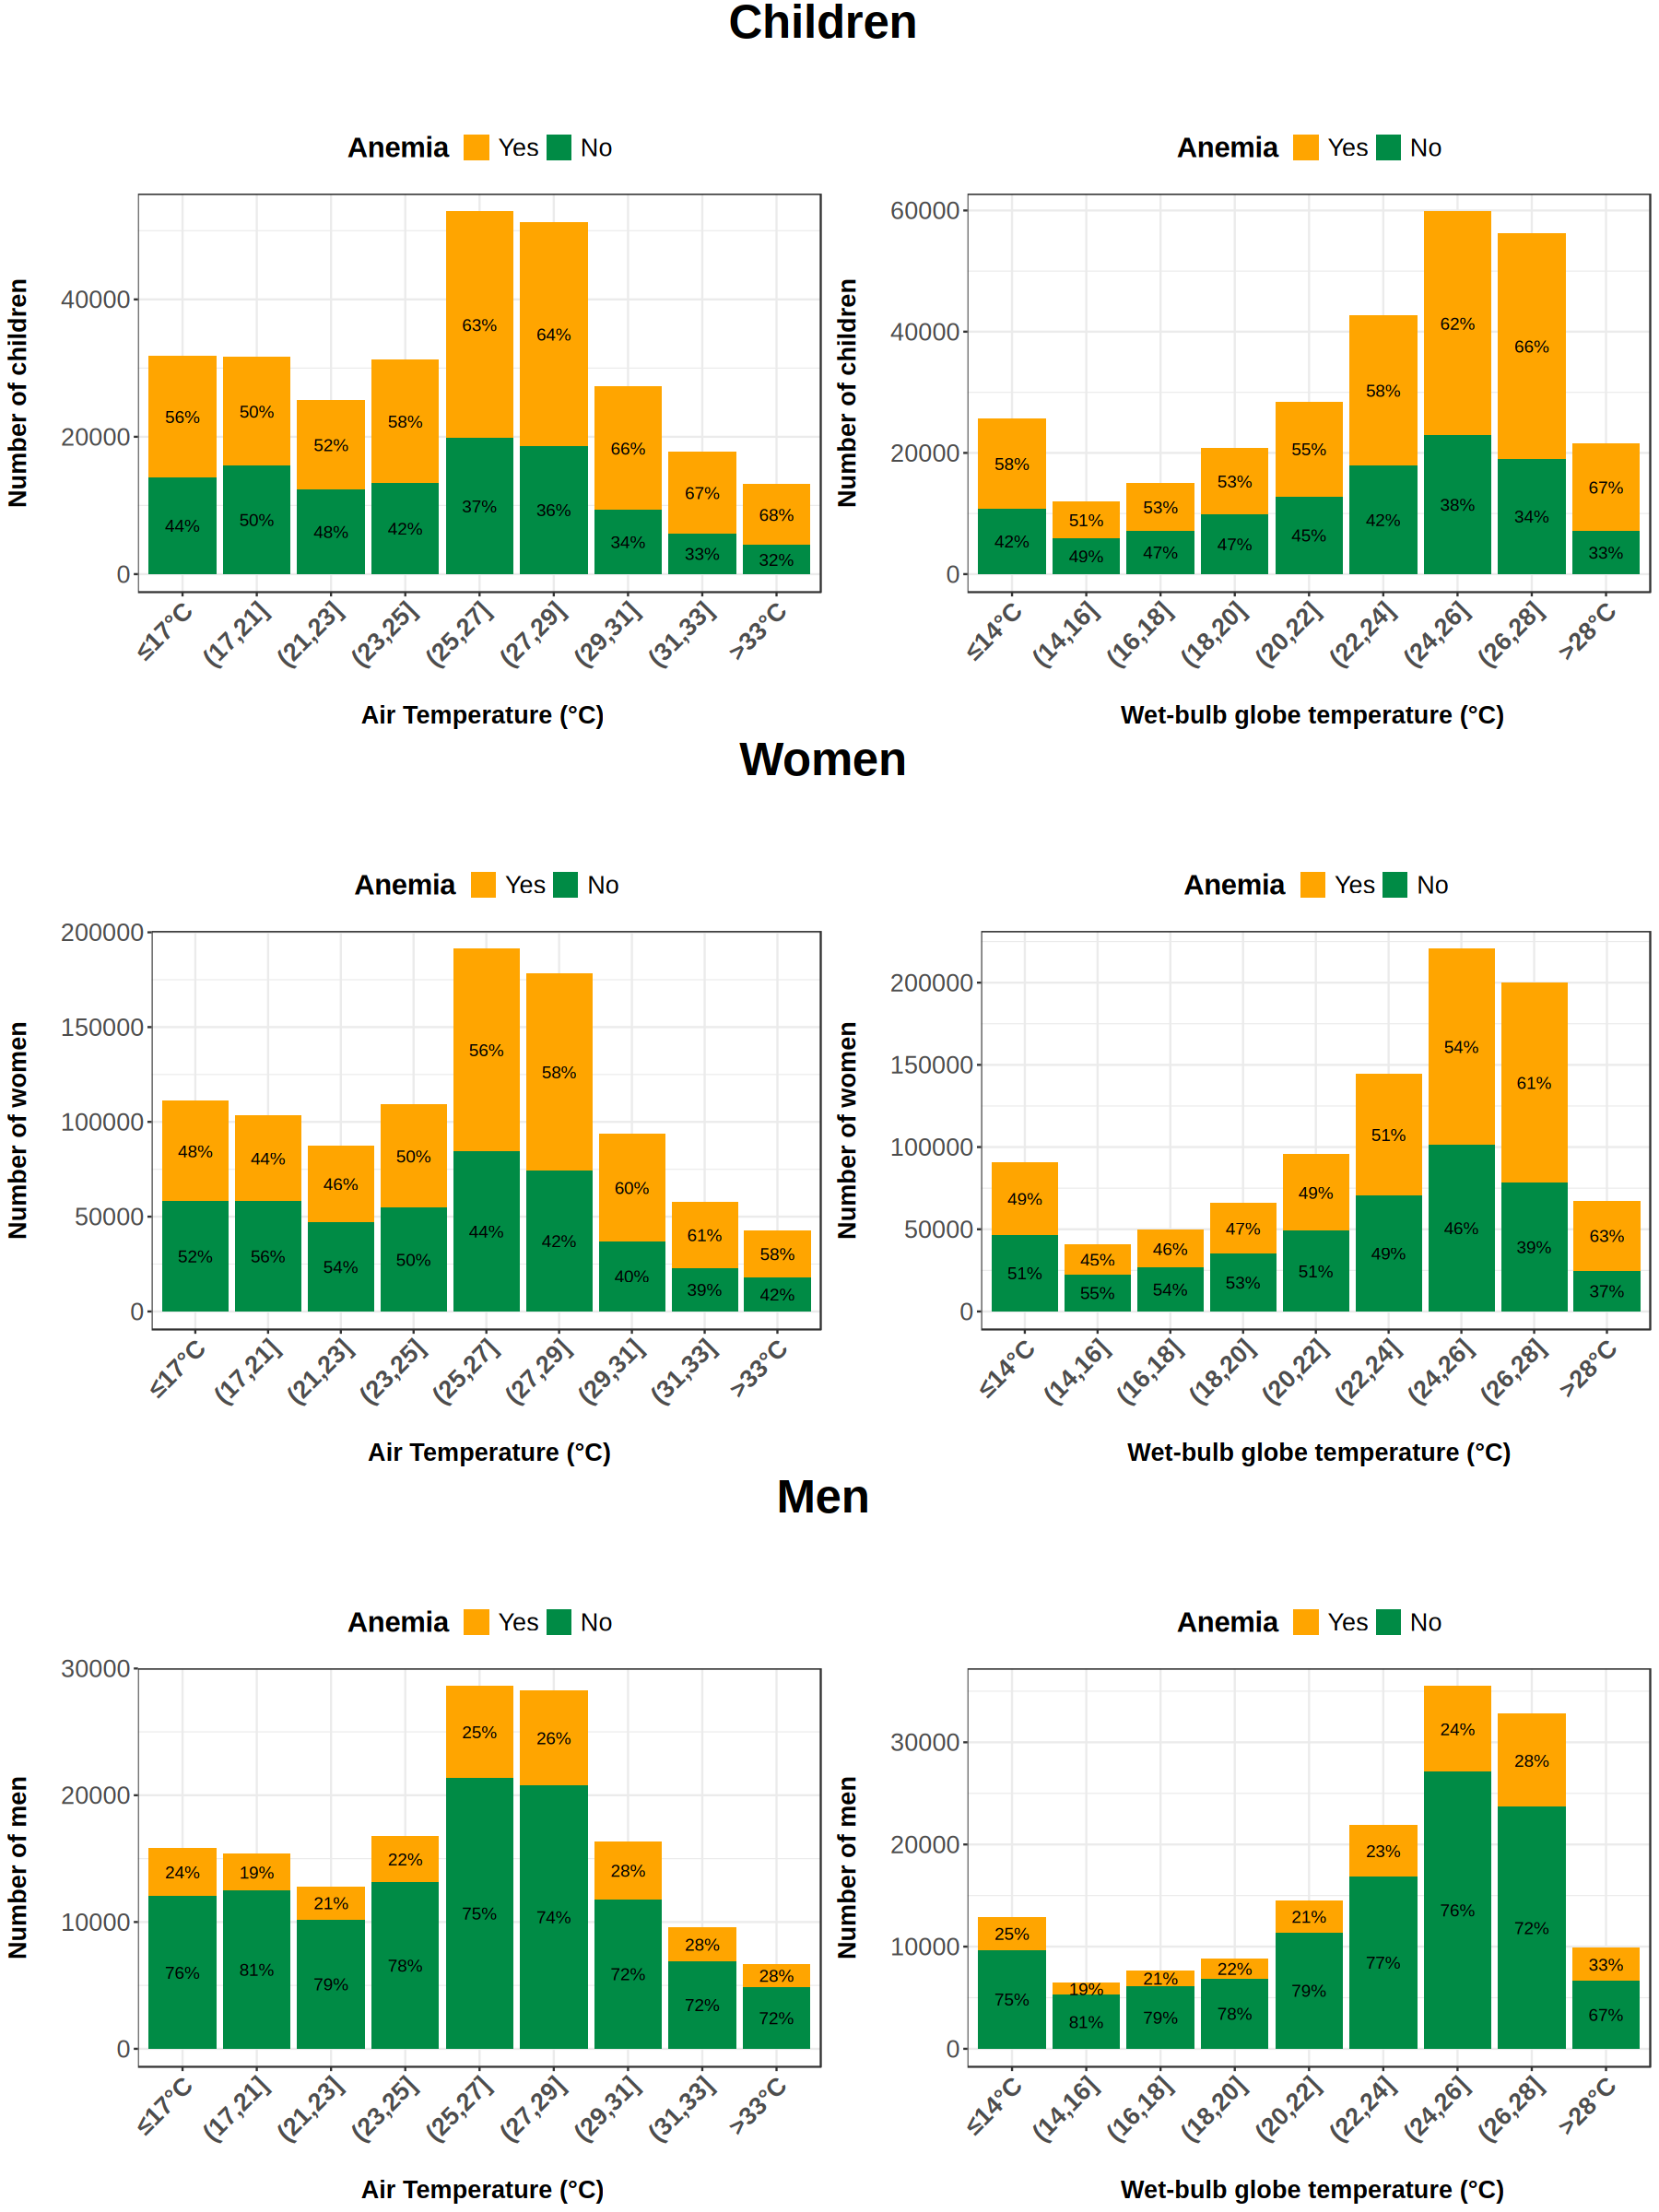

In [20]:
options(repr.plot.width=15, repr.plot.height=20, scipen=9999)

plot_all <- ggarrange(plot_children,plot_women,plot_men,
                      nrow=3)
plot_all

In [21]:
ggsave("./3_output/img/anemia_per_T_WB_bins.png", plot = plot_all, width = 18, height = 20, device = "png")